In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('OpenAlexData.csv', index_col=0)

C:\Users\wieke\AppData\Local\Temp\ipykernel_33340\2055085896.py:1: DtypeWarning: Columns (8,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('OpenAlexData.csv', index_col=0)


In [25]:
pd.set_option("display.max_columns", 55)


In [26]:
def counts(col1, col2, col3, df):
    oa_count_s = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col3] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    oa_count_s
    return oa_count_s.sort_values(by=[col3], ascending=False)
    



In [27]:
def multiple_counts(col1, col2, col3, col4, df):
    oa_count_s = df.groupby([col1, col2])[col3].value_counts().unstack(col3).reset_index()
    oa_count_s = oa_count_s.fillna(0)
    
    oa_count_s[col4] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
    
    return oa_count_s


In [28]:
def oa_status(df, col1, col2, sorted):
    oa_status_df = df.groupby([col1])[col2].value_counts().unstack(col2).reset_index()
    oa_status_df = oa_status_df.fillna(0)
    oa_status_df['total'] = oa_status_df['bronze'] + oa_status_df['closed'] + oa_status_df['gold'] + oa_status_df['green'] + oa_status_df['hybrid']
    oa_status_df['hybrid %'] = oa_status_df['hybrid'] / oa_status_df['total']
    oa_status_df['green %'] = oa_status_df['green'] / oa_status_df['total']
    oa_status_df['gold %'] = oa_status_df['gold'] / oa_status_df['total']
    oa_status_df['closed %'] = oa_status_df['closed'] / oa_status_df['total']
    oa_status_df['bronze %'] = oa_status_df['bronze'] / oa_status_df['total']
    dct = {'hybrid %': 'hybrid', 'green %': 'green', 'gold %': 'gold', 'closed %': 'closed', 'bronze %': 'bronze'}
    oa_status_df['Most used OA type'] = oa_status_df[['hybrid %', 'green %', 'gold %', 'closed %', 'bronze %']].idxmax(axis=1).map(dct)

    #oa_status_df = oa_status_df.sort_values(by=[sort], ascending=False)
    oa_status_df = oa_status_df.sort_values(by=[sorted], ascending=False).reset_index(drop=True)

    return oa_status_df

In [29]:
df

,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
0,https://openalex.org/W213417050,https://doi.org/10.1037/e675542012-001,dataset,funder,Cognitive Therapy for Depression,2012,2012-01-01,en,https://openalex.org/T11071,Treatment of Major Depression,https://openalex.org/subfields/2736,Pharmacology,https://openalex.org/fields/27,Medicine,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5059319052,Aaron T. Beck,last,https://orcid.org/0000-0001-6210-9528,https://openalex.org/I79576946,University of Pennsylvania,"Psychology,University of Pennsylvania",US,https://ror.org/00b30xv10,https://openalex.org/I79576946
1,https://openalex.org/W2913255424,https://doi.org/10.1037/e566732013-001,dataset,funder,Best Practices for Mixed Methods Research in H...,2011,2011-01-01,en,https://openalex.org/T10629,Health Policy Implementation Science,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5025339678,John W. Creswell,first,https://orcid.org/0000-0002-5006-880X,https://openalex.org/I114395901,University of Nebraska–Lincoln,University of Nebraska— Lincoln,US,https://ror.org/043mer456,https://openalex.org/I114395901
2,https://openalex.org/W2913255424,https://doi.org/10.1037/e566732013-001,dataset,funder,Best Practices for Mixed Methods Research in H...,2011,2011-01-01,en,https://openalex.org/T10629,Health Policy Implementation Science,https://openalex.org/subfields/3600,General Health Professions,https://openalex.org/fields/36,Health Professions,https://openalex.org/domains/4,Health Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5021840711,Vicki L. Plano Clark,middle,https://orcid.org/0000-0002-9709-7982,https://openalex.org/I114395901,University of Nebraska–Lincoln,University of Nebraska— Lincoln,US,https://ror.org/043mer456,https://openalex.org/I114395901
3,https://openalex.org/W1639235375,https://doi.org/10.1037/e671332011-001,dataset,funder,The Loss of Sadness: How Psychiatry Transforme...,2009,2009-01-01,en,https://openalex.org/T12308,Mental Health and Psychiatry,https://openalex.org/subfields/1211,Philosophy,https://openalex.org/fields/12,Arts and Humanities,https://openalex.org/domains/2,Social Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5091505956,Jerome C. Wakefield,last,https://orcid.org/0000-0002-6809-5515,https://openalex.org/I57206974,New York University,"New York University, New York, NY, US",US,https://ror.org/0190ak572,https://openalex.org/I57206974
4,https://openalex.org/W2995669665,https://doi.org/10.1037/e555342011-003,dataset,funder,Cognitive Therapy for Depression,1996,1996-01-01,en,https://openalex.org/T13272,Psychological Treatments and Assessments,https://openalex.org/subfields/3203,Clinical Psychology,https://openalex.org/fields/32,Psychology,https://openalex.org/domains/2,Social Sciences,False,crossref,PsycEXTRA Dataset,False,closed,NaN,https://openalex.org/A5047792029,Aaron T. Beck,last,NaN,https://openalex.org/I79576946,University of Pennsylvania,"Department of Psychiatry, School of Medicine, ...",US,https://ror.org/00b30xv10,https://openalex.org/I79576946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517775,https://openalex.org/W4210334465,https://doi.org/10.3886/icpsr01011.v1,dataset,funder,Incentive Effects of Tournaments Revisited: Ev...,1996,1996-01-03,en,https://openalex.org/T11705,Gambling Behavior and Treatments,https:

In [30]:
institutions_df = counts('institution_name', 'is_oa', 'OA %', df).reset_index(drop=True)
institutions_df

is_oa,institution_name,False,True,OA %
0,University of Michigan–Ann Arbor,2840,445922,0.993671
1,Princeton University,712,5718,0.889269
2,Virginia Tech,170,907,0.842154
3,Michael J. Fox Foundation,1,5,0.833333
4,New York University,1092,4345,0.799154
5,Pennsylvania State University,934,3266,0.777619
6,Cornell University,3549,8320,0.700986
7,University of Virginia,1020,2099,0.672972
8,University of Colorado Boulder,476,954,0.667133
9,University of Pennsylvania,1159,2216,0.656593


In [31]:
df['oa_status'].value_counts()

oa_status
hybrid    435283
gold       48314
closed     29063
bronze      4714
green        406
Name: count, dtype: int64

In [32]:
df['Repository'].unique()

array(['PsycEXTRA Dataset', 'Harvard Dataverse',
       'Artifact Digital Object Group', 'Figshare',
       'Zenodo (CERN European Organization for Nuclear Research)',
       'Global Biodiversity Information Facility', nan,
       'The SHAFR Guide Online',
       'Carbon Dioxide Information Analysis Center (CDIAC) Datasets',
       'IUPAC Standards Online', 'AEA Randomized Controlled Trials',
       'immuneACCESS',
       'Pancreapedia: The Exocrine Pancreas Knowledge Base',
       'ICPSR Data Holdings', 'Forest Service Research Data Archive',
       'OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)',
       'PsycTESTS Dataset',
       'Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature',
       'Authorea', 'nano Online', 'Human Rights Documents online',
       'ENCODE Datasets', 'The Winnower',
       'Biological and Chemical Oceanography Data Management Office',
       'energyo', 'EcoSal',
       'APS Division of Plasma Phy

In [33]:
# remove faculty opinions as it is not a dataset content
df= df[df['Repository'] != 'Faculty Opinions – Post-Publication Peer Review of the Biomedical Literature']

# remove encode if wanting to remove this scope
encode_removed_df = df[(df['Repository'] != 'ENCODE Datasets')]

In [34]:
Michigan_df = df[df['institution_name'] == 'University of Michigan–Ann Arbor']
#ror_df = unnested_df[(unnested_df['ror'] == 'https://ror.org/0190ak572')]
Michigan_df['Repository'].value_counts()

Repository
ENCODE Datasets                                                                        434717
Harvard Dataverse                                                                        9034
Zenodo (CERN European Organization for Nuclear Research)                                 1422
Figshare                                                                                  554
IUPAC Standards Online                                                                    145
OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)        72
Default Digital Object Group                                                               60
PsycEXTRA Dataset                                                                          59
Pancreapedia: The Exocrine Pancreas Knowledge Base                                         51
AEA Randomized Controlled Trials                                                           25
Authorea                                         

In [35]:
Michigan_df.groupby(['Repository', 'publication_year']).size().sort_values(ascending=False).head(15)


Repository                                                publication_year
ENCODE Datasets                                           2022                434618
Harvard Dataverse                                         2020                  3823
                                                          2019                  3565
                                                          2012                   584
Zenodo (CERN European Organization for Nuclear Research)  2023                   429
                                                          2021                   370
Figshare                                                  2023                   363
Harvard Dataverse                                         2018                   257
Zenodo (CERN European Organization for Nuclear Research)  2022                   244
                                                          2020                   190
Harvard Dataverse                                         2017             

In [36]:
encode_test = df[(df['Repository'] == 'ENCODE Datasets')]
len(encode_test) 

435461

In [37]:
df2022 = df[df['publication_year'] >= 2022]
df2021 = df[df['publication_year'] <= 2021]

In [38]:
df['Repository'].unique()

array(['PsycEXTRA Dataset', 'Harvard Dataverse',
       'Artifact Digital Object Group', 'Figshare',
       'Zenodo (CERN European Organization for Nuclear Research)',
       'Global Biodiversity Information Facility', nan,
       'The SHAFR Guide Online',
       'Carbon Dioxide Information Analysis Center (CDIAC) Datasets',
       'IUPAC Standards Online', 'AEA Randomized Controlled Trials',
       'immuneACCESS',
       'Pancreapedia: The Exocrine Pancreas Knowledge Base',
       'ICPSR Data Holdings', 'Forest Service Research Data Archive',
       'OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)',
       'PsycTESTS Dataset', 'Authorea', 'nano Online',
       'Human Rights Documents online', 'ENCODE Datasets', 'The Winnower',
       'Biological and Chemical Oceanography Data Management Office',
       'energyo', 'EcoSal',
       'APS Division of Plasma Physics Meeting Abstracts',
       'Default Digital Object Group', 'SciVee', 'Radiographics',
   

In [39]:
inst_domain_df = df.groupby(['institution_name', 'domain_name']).size().sort_values(ascending=False)
inst_domain_df.head(50)

institution_name                         domain_name      
University of Michigan–Ann Arbor         Physical Sciences    18264
                                         Life Sciences         8274
Cornell University                       Physical Sciences     7408
Washington University in St. Louis       Physical Sciences     5308
University of Michigan–Ann Arbor         Health Sciences       5108
                                         Social Sciences       5094
University of Wisconsin–Madison          Physical Sciences     3985
Duke University                          Physical Sciences     3019
Princeton University                     Physical Sciences     2183
University of Nebraska–Lincoln           Physical Sciences     1901
Pennsylvania State University            Physical Sciences     1544
New York University                      Social Sciences       1285
Princeton University                     Social Sciences       1257
New York University                      Physical Science

In [40]:
oa_count_df = df.groupby(['institution_name', 'is_oa']).size().sort_values(ascending=False)
oa_count_df.head(25)


institution_name                         is_oa
University of Michigan–Ann Arbor         True     445209
Cornell University                       True       7972
Princeton University                     True       5568
Washington University in St. Louis       False      4835
Duke University                          True       4114
New York University                      True       4105
University of Wisconsin–Madison          True       3446
Pennsylvania State University            True       3098
Washington University in St. Louis       True       2545
University of Wisconsin–Madison          False      2392
Cornell University                       False      2332
Duke University                          False      2256
University of Pennsylvania               True       1881
University of Virginia                   True       1781
University of Nebraska–Lincoln           False      1774
University of Illinois Urbana-Champaign  True       1639
University of Michigan–Ann Arbor         

In [41]:
oa_count_df = df.groupby(['institution_name'])['is_oa'].value_counts().unstack('is_oa').reset_index()
oa_count_df


is_oa,institution_name,False,True
0,Cornell University,2332,7972
1,Duke University,2256,4114
2,Michael J. Fox Foundation,1,5
3,New York University,305,4105
4,Pennsylvania State University,448,3098
5,Princeton University,219,5568
6,University of Colorado Boulder,95,855
7,University of Illinois Urbana-Champaign,354,1639
8,University of Michigan–Ann Arbor,998,445209
9,University of Minnesota,347,736


In [42]:
df['Repository'].value_counts()

Repository
ENCODE Datasets                                                                        435461
Harvard Dataverse                                                                       30117
Zenodo (CERN European Organization for Nuclear Research)                                16798
OSTI OAI (U.S. Department of Energy Office of Scientific and Technical Information)     13256
Figshare                                                                                 2976
IUPAC Standards Online                                                                    915
Default Digital Object Group                                                              579
PsycEXTRA Dataset                                                                         370
Authorea                                                                                  102
Artifact Digital Object Group                                                             101
energyo                                          

In [43]:
oa_count_s = df.groupby(['institution_name'])['is_oa'].value_counts().unstack('is_oa').reset_index()
oa_count_s['OA %'] = oa_count_s[True] / (oa_count_s[False] + oa_count_s[True])
#oa_count_s
oa_count_s.sort_values(by=['OA %'], ascending=False)

is_oa,institution_name,False,True,OA %
8,University of Michigan–Ann Arbor,998,445209,0.997763
12,University of Pennsylvania,69,1881,0.964615
5,Princeton University,219,5568,0.962157
3,New York University,305,4105,0.930839
6,University of Colorado Boulder,95,855,0.900000
13,University of Virginia,216,1781,0.891838
15,Virginia Tech,120,891,0.881306
4,Pennsylvania State University,448,3098,0.873660
2,Michael J. Fox Foundation,1,5,0.833333
7,University of Illinois Urbana-Champaign,354,1639,0.822378


In [44]:
field_oa_df = counts('field_name', 'is_oa', 'OA %', df)
field_oa_df 

is_oa,field_name,False,True,OA %
20,Nursing,0.0,40.0,1.000000
8,Dentistry,0.0,94.0,1.000000
10,"Economics, Econometrics and Finance",9.0,2279.0,0.996066
5,Chemistry,80.0,6237.0,0.987336
14,Health Professions,6.0,405.0,0.985401
3,"Business, Management and Accounting",22.0,1478.0,0.985333
24,Social Sciences,115.0,6725.0,0.983187
17,Mathematics,10.0,453.0,0.978402
7,Decision Sciences,48.0,2139.0,0.978052
15,Immunology and Microbiology,17.0,510.0,0.967742


In [45]:
domain_oa_df = counts('domain_name', 'is_oa', 'OA %', df)
domain_oa_df


is_oa,domain_name,False,True,OA %
3,Social Sciences,286,13262,0.978890
0,Health Sciences,321,7561,0.959274
1,Life Sciences,652,12368,0.949923
2,Physical Sciences,14527,33534,0.697738


In [46]:
subfield_name_df = counts('subfield_name', 'is_oa', 'OA %', df)
subfield_name_df.head(25)


is_oa,subfield_name,False,True,OA %
159,Oral Surgery,0.0,3.0,1.0
103,Health,0.0,94.0,1.0
169,Periodontics,0.0,90.0,1.0
38,Classics,0.0,3.0,1.0
125,Law,0.0,147.0,1.0
123,"Issues, ethics and legal aspects",0.0,3.0,1.0
43,Complementary and alternative medicine,0.0,50.0,1.0
172,Pharmacy,0.0,9.0,1.0
46,Computer Graphics and Computer-Aided Design,0.0,59.0,1.0
115,Industrial relations,0.0,8.0,1.0


In [47]:
topic_name_df = counts('topic_name', 'is_oa', 'OA %', df)
topic_name_df.head(25)

is_oa,topic_name,False,True,OA %
0,2D Materials and Applications,0.0,6.0,1.0
1378,Microbial bioremediation and biosurfactants,0.0,3.0,1.0
1395,Migration and Labor Dynamics,0.0,102.0,1.0
1394,Migraine and Headache Studies,0.0,2.0,1.0
1393,Middle East and Rwanda Conflicts,0.0,7.0,1.0
1392,Middle East Politics and Society,0.0,46.0,1.0
1391,Microwave-Assisted Synthesis and Applications,0.0,3.0,1.0
1390,Microwave and Dielectric Measurement Techniques,0.0,2.0,1.0
1389,Microwave Imaging and Scattering Analysis,0.0,2.0,1.0
1388,Microwave Engineering and Waveguides,0.0,2.0,1.0


In [48]:
MN_df = df[df['institution_name'] == 'University of Minnesota']
MN_df

,id,doi,type,funding_type,title,publication_year,publication_date,language,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name,retracted,index location,Repository,is_oa,oa_status,license,author_id,author_name,author_position,orcid,institution_id,institution_name,raw_affiliation_strings,country_code,ror,lineage
6,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5016996755,Claire Porter,first,https://orcid.org/0009-0005-4979-9778,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
7,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5074382278,Paul Morin,middle,https://orcid.org/0000-0002-4512-0642,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
9,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5114168374,Cole Kelleher,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
10,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5111210501,Michael Cloutier,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
11,https://openalex.org/W4398549858,https://doi.org/10.7910/dvn/ohhukh,dataset,funder,"ArcticDEM, Version 3",2018,2018-01-01,en,https://openalex.org/T10995,Methane Hydrates and Related Phenomena,https://openalex.org/subfields/2304,Environmental Chemistry,https://openalex.org/fields/23,Environmental Science,https://openalex.org/domains/3,Physical Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,https://openalex.org/A5098790376,Eric Husby,middle,NaN,https://openalex.org/I130238516,University of Minnesota,(University of Minnesota),US,https://ror.org/017zqws13,https://openalex.org/I130238516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517323,https://openalex.org/W4398340829,https://doi.org/10.7910/dvn/awsqtw,dataset,funder,Replication Data for: Parties as Disciplinaria...,2021,2021-01-01,en,https://openalex.org/T10557,Social Media and Politics,https://openalex.org/subfields/3315,Communication,https://openalex.org/fields/33,Social Sciences,https://openalex.org/domains/2,Social Sciences,False,datacite,Harvard Dataverse,True,gold,other-oa,

In [49]:
funding_oa_status_df = oa_status(df, 'funding_type', 'oa_status', 'green %')
funding_oa_status_df

oa_status,funding_type,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,funder,682.0,16789.0,48307.0,406.0,435250.0,501434.0,0.868011,0.00081,0.096338,0.033482,0.00136,hybrid
1,education,0.0,0.0,2.0,0.0,2.0,4.0,0.500000,0.00000,0.500000,0.000000,0.00000,hybrid
2,nonprofit,0.0,1.0,5.0,0.0,0.0,6.0,0.000000,0.00000,0.833333,0.166667,0.00000,gold


In [50]:
MN_oa_df = counts('field_name', 'is_oa', 'OA %', MN_df)
MN_oa_df

is_oa,field_name,False,True,OA %
8,"Economics, Econometrics and Finance",0.0,36.0,1.000000
15,Mathematics,0.0,7.0,1.000000
3,"Business, Management and Accounting",0.0,19.0,1.000000
6,Decision Sciences,0.0,17.0,1.000000
9,Energy,0.0,4.0,1.000000
1,Arts and Humanities,0.0,4.0,1.000000
12,Health Professions,0.0,1.0,1.000000
20,Social Sciences,2.0,117.0,0.983193
18,Physics and Astronomy,6.0,77.0,0.927711
19,Psychology,1.0,10.0,0.909091


In [51]:
pub_year_df = counts('publication_year', 'is_oa', 'OA %', df)
pub_year_df

is_oa,publication_year,False,True,OA %
17,1997,0.0,7.0,1.000000
3,1969,0.0,1.0,1.000000
4,1972,0.0,1.0,1.000000
7,1980,0.0,2.0,1.000000
8,1982,0.0,2.0,1.000000
9,1984,0.0,3.0,1.000000
1,1960,0.0,1.0,1.000000
27,2007,2.0,877.0,0.997725
42,2022,9181.0,439093.0,0.979519
38,2018,153.0,4222.0,0.965029


In [52]:
inst_oa_status_df = oa_status(df, 'institution_name', 'oa_status', 'green %')
inst_oa_status_df

oa_status,institution_name,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,University of New Mexico,5.0,29.0,64.0,8.0,8.0,114.0,0.070175,0.070175,0.561404,0.254386,0.043860,gold
1,University of Pennsylvania,13.0,69.0,1793.0,67.0,8.0,1950.0,0.004103,0.034359,0.919487,0.035385,0.006667,gold
2,Virginia Tech,66.0,120.0,752.0,26.0,47.0,1011.0,0.046489,0.025717,0.743818,0.118694,0.065282,gold
3,University of Illinois Urbana-Champaign,25.0,354.0,1570.0,29.0,15.0,1993.0,0.007526,0.014551,0.787757,0.177622,0.012544,gold
4,University of Colorado Boulder,12.0,95.0,825.0,11.0,7.0,950.0,0.007368,0.011579,0.868421,0.100000,0.012632,gold
5,University of Minnesota,33.0,347.0,686.0,9.0,8.0,1083.0,0.007387,0.008310,0.633426,0.320406,0.030471,gold
6,University of Virginia,18.0,216.0,1748.0,14.0,1.0,1997.0,0.000501,0.007011,0.875313,0.108162,0.009014,gold
7,University of Nebraska–Lincoln,3.0,1774.0,701.0,17.0,3.0,2498.0,0.001201,0.006805,0.280624,0.710168,0.001201,closed
8,Duke University,125.0,2256.0,3382.0,42.0,565.0,6370.0,0.088697,0.006593,0.530926,0.354160,0.019623,gold
9,University of Wisconsin–Madison,26.0,2392.0,3354.0,32.0,34.0,5838.0,0.005824,0.005481,0.574512,0.409729,0.004454,gold


In [53]:
field_oa_status_df = oa_status(df,  'field_name', 'oa_status', 'green %')
field_oa_status_df

oa_status,field_name,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,Psychology,20.0,57.0,284.0,80.0,2.0,443.0,0.004515,0.180587,0.641084,0.128668,0.045147,gold
1,Nursing,1.0,0.0,35.0,4.0,0.0,40.0,0.000000,0.100000,0.875000,0.000000,0.025000,gold
2,Arts and Humanities,4.0,35.0,187.0,12.0,52.0,290.0,0.179310,0.041379,0.644828,0.120690,0.013793,gold
3,Immunology and Microbiology,2.0,17.0,273.0,16.0,219.0,527.0,0.415560,0.030361,0.518027,0.032258,0.003795,gold
4,Health Professions,1.0,6.0,246.0,11.0,147.0,411.0,0.357664,0.026764,0.598540,0.014599,0.002433,gold
5,Neuroscience,1.0,117.0,345.0,9.0,10.0,482.0,0.020747,0.018672,0.715768,0.242739,0.002075,gold
6,Social Sciences,22.0,115.0,5299.0,84.0,1320.0,6840.0,0.192982,0.012281,0.774708,0.016813,0.003216,gold
7,Decision Sciences,0.0,48.0,1062.0,22.0,1055.0,2187.0,0.482396,0.010059,0.485597,0.021948,0.000000,gold
8,Mathematics,1.0,10.0,447.0,3.0,2.0,463.0,0.004320,0.006479,0.965443,0.021598,0.002160,gold
9,Engineering,177.0,422.0,3219.0,30.0,2933.0,6781.0,0.432532,0.004424,0.474709,0.062233,0.026102,gold


In [54]:
license_oa_status_df = oa_status(df,  'license', 'oa_status', 'gold %')
license_oa_status_df


oa_status,license,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,cc-by-nd,0.0,0.0,4.0,0.0,0.0,4.0,0.000000,0.000000,1.000000,0.000000,0.00000,gold
1,other-oa,0.0,29.0,31883.0,9.0,3.0,31924.0,0.000094,0.000282,0.998716,0.000908,0.00000,gold
2,cc-by-sa,0.0,1.0,48.0,0.0,0.0,49.0,0.000000,0.000000,0.979592,0.020408,0.00000,gold
3,gpl-v3,0.0,3.0,60.0,0.0,0.0,63.0,0.000000,0.000000,0.952381,0.047619,0.00000,gold
4,mit,0.0,10.0,66.0,0.0,8.0,84.0,0.095238,0.000000,0.785714,0.119048,0.00000,gold
5,cc-by-nc-nd,0.0,12.0,24.0,0.0,1.0,37.0,0.027027,0.000000,0.648649,0.324324,0.00000,gold
6,cc-by-nc,0.0,1.0,92.0,0.0,71.0,164.0,0.432927,0.000000,0.560976,0.006098,0.00000,gold
7,cc-by-nc-sa,0.0,18.0,11.0,0.0,1.0,30.0,0.033333,0.000000,0.366667,0.600000,0.00000,closed
8,apache-2-0,0.0,11.0,5.0,0.0,0.0,16.0,0.000000,0.000000,0.312500,0.687500,0.00000,closed
9,cc-by,9.0,838.0,15920.0,19.0,435062.0,451848.0,0.962850,0.000042,0.035233,0.001855,0.00002,hybrid


In [55]:
index_oa_status_df = oa_status(df, 'index location', 'oa_status', 'green %')
index_oa_status_df

oa_status,index location,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,arxiv,0.0,0.0,0.0,13.0,0.0,13.0,0.000000,1.000000,0.000000,0.000000,0.000000,green
1,crossref,673.0,1994.0,0.0,349.0,435249.0,438265.0,0.993118,0.000796,0.000000,0.004550,0.001536,hybrid
2,datacite,9.0,1555.0,48314.0,21.0,3.0,49902.0,0.000060,0.000421,0.968178,0.031161,0.000180,gold


In [56]:
repo_oa_status_df = oa_status(df, 'Repository', 'oa_status', 'green %')
repo_oa_status_df

oa_status,Repository,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,nano Online,0.0,0.0,0.0,3.0,0.0,3.0,0.000000,1.000000,0.000000,0.000000,0.000000,green
1,immuneACCESS,0.0,0.0,0.0,23.0,0.0,23.0,0.000000,1.000000,0.000000,0.000000,0.000000,green
2,EcoSal,0.0,0.0,0.0,4.0,0.0,4.0,0.000000,1.000000,0.000000,0.000000,0.000000,green
3,Human Rights Documents online,0.0,1.0,0.0,7.0,0.0,8.0,0.000000,0.875000,0.000000,0.125000,0.000000,green
4,ICPSR Data Holdings,0.0,2.0,0.0,10.0,0.0,12.0,0.000000,0.833333,0.000000,0.166667,0.000000,green
5,"Research Data Repository, Duke University",0.0,0.0,0.0,4.0,1.0,5.0,0.200000,0.800000,0.000000,0.000000,0.000000,green
6,Carbon Dioxide Information Analysis Center (CD...,0.0,3.0,0.0,6.0,0.0,9.0,0.000000,0.666667,0.000000,0.333333,0.000000,green
7,PsycEXTRA Dataset,7.0,145.0,0.0,218.0,0.0,370.0,0.000000,0.589189,0.000000,0.391892,0.018919,green
8,Oxford Bibliographies Online Datasets,0.0,1.0,0.0,1.0,0.0,2.0,0.000000,0.500000,0.000000,0.500000,0.000000,green
9,PsycTESTS Dataset,0.0,5.0,0.0,2.0,0.0,7.0,0.000000,0.285714,0.000000,0.714286,0.000000,closed


In [57]:
repo_oa_status_df = counts('Repository', 'is_oa', 'OA %', df).reset_index(drop=True)
repo_oa_status_df

is_oa,Repository,False,True,OA %
0,AEA Randomized Controlled Trials,0.0,51.0,1.000000
1,EcoSal,0.0,4.0,1.000000
2,immuneACCESS,0.0,23.0,1.000000
3,Wolfram Demonstrations Project,0.0,1.0,1.000000
4,The Winnower,0.0,11.0,1.000000
5,"Research Data Repository, Duke University",0.0,5.0,1.000000
6,Pancreapedia: The Exocrine Pancreas Knowledge ...,0.0,71.0,1.000000
7,Harvard Dataverse,0.0,30117.0,1.000000
8,Global Biodiversity Information Facility,0.0,18.0,1.000000
9,nano Online,0.0,3.0,1.000000


In [58]:
institutions_df = counts('institution_name', 'is_oa', 'OA %', df).reset_index(drop=True)
institutions_df

is_oa,institution_name,False,True,OA %
0,University of Michigan–Ann Arbor,998,445209,0.997763
1,University of Pennsylvania,69,1881,0.964615
2,Princeton University,219,5568,0.962157
3,New York University,305,4105,0.930839
4,University of Colorado Boulder,95,855,0.900000
5,University of Virginia,216,1781,0.891838
6,Virginia Tech,120,891,0.881306
7,Pennsylvania State University,448,3098,0.873660
8,Michael J. Fox Foundation,1,5,0.833333
9,University of Illinois Urbana-Champaign,354,1639,0.822378


In [59]:
institutions_2022df = counts('institution_name', 'is_oa', 'OA %', df2022).reset_index(drop=True)
institutions_2022df 

is_oa,institution_name,False,True,OA %
0,University of Michigan–Ann Arbor,711,435365,0.998370
1,University of Virginia,26,448,0.945148
2,University of Pennsylvania,26,230,0.898438
3,New York University,83,726,0.897404
4,Virginia Tech,59,494,0.893309
5,University of Colorado Boulder,21,152,0.878613
6,Princeton University,141,843,0.856707
7,Michael J. Fox Foundation,1,5,0.833333
8,University of New Mexico,6,28,0.823529
9,Pennsylvania State University,191,796,0.806484


In [60]:
institutions_2021df = counts('institution_name', 'is_oa', 'OA %', df2021).reset_index(drop=True)
institutions_2021df 

is_oa,institution_name,False,True,OA %
0,Princeton University,78,4725,0.983760
1,University of Pennsylvania,43,1651,0.974616
2,University of Michigan–Ann Arbor,287,9844,0.971671
3,Cornell University,261,6837,0.963229
4,New York University,222,3379,0.938350
5,University of Colorado Boulder,74,703,0.904762
6,Pennsylvania State University,257,2302,0.899570
7,University of Virginia,190,1333,0.875246
8,Virginia Tech,61,397,0.866812
9,Washington University in St. Louis,284,1848,0.866792


In [61]:
MN_df = df[df['institution_name'] == 'University of Minnesota']
MN_2022df = df2022[df2022['institution_name'] == 'University of Minnesota']
MN_2021df = df2021[df2021['institution_name'] == 'University of Minnesota']


In [62]:
MN_2021_repo_df = counts('Repository', 'is_oa', 'OA %', MN_2021df).reset_index(drop=True)
MN_2021_repo_df 

is_oa,Repository,False,True,OA %
0,Figshare,0.0,12.0,1.000000
1,Harvard Dataverse,0.0,362.0,1.000000
2,Pancreapedia: The Exocrine Pancreas Knowledge ...,0.0,5.0,1.000000
3,Zenodo (CERN European Organization for Nuclear...,0.0,102.0,1.000000
4,energyo,0.0,1.0,1.000000
5,immuneACCESS,0.0,1.0,1.000000
6,IUPAC Standards Online,6.0,26.0,0.812500
7,PsycEXTRA Dataset,2.0,8.0,0.800000
8,Default Digital Object Group,47.0,9.0,0.160714
9,OSTI OAI (U.S. Department of Energy Office of ...,26.0,0.0,0.000000


In [63]:
MN_2022_repo_df = counts('Repository', 'is_oa', 'OA %', MN_2022df).reset_index(drop=True)
MN_2022_repo_df 

is_oa,Repository,False,True,OA %
0,Harvard Dataverse,0.0,90.0,1.000000
1,Zenodo (CERN European Organization for Nuclear...,23.0,120.0,0.839161
2,Artifact Digital Object Group,4.0,0.0,0.000000
3,Default Digital Object Group,4.0,0.0,0.000000
4,IUPAC Standards Online,214.0,0.0,0.000000
5,OSTI OAI (U.S. Department of Energy Office of ...,14.0,0.0,0.000000


In [64]:
counts('field_name', 'is_oa', 'OA %', MN_2022df).reset_index(drop=True)

is_oa,field_name,False,True,OA %
0,Health Professions,0.0,1.0,1.000000
1,"Business, Management and Accounting",0.0,2.0,1.000000
2,Social Sciences,0.0,12.0,1.000000
3,Decision Sciences,0.0,3.0,1.000000
4,"Economics, Econometrics and Finance",0.0,9.0,1.000000
5,Physics and Astronomy,5.0,47.0,0.903846
6,Earth and Planetary Sciences,4.0,34.0,0.894737
7,Engineering,5.0,30.0,0.857143
8,Agricultural and Biological Sciences,4.0,17.0,0.809524
9,Chemistry,11.0,27.0,0.710526


In [65]:
MN_2022df.groupby(['field_name', 'Repository', 'is_oa']).size().unstack('is_oa').reset_index() #sort_values(by=[0], ascending=False)


is_oa,field_name,Repository,False,True
0,Agricultural and Biological Sciences,Harvard Dataverse,NaN,5.0
1,Agricultural and Biological Sciences,OSTI OAI (U.S. Department of Energy Office of ...,4.0,NaN
2,Agricultural and Biological Sciences,Zenodo (CERN European Organization for Nuclear...,NaN,12.0
3,"Biochemistry, Genetics and Molecular Biology",Harvard Dataverse,NaN,1.0
4,"Biochemistry, Genetics and Molecular Biology",IUPAC Standards Online,33.0,NaN
5,"Biochemistry, Genetics and Molecular Biology",OSTI OAI (U.S. Department of Energy Office of ...,1.0,NaN
6,"Biochemistry, Genetics and Molecular Biology",Zenodo (CERN European Organization for Nuclear...,4.0,NaN
7,"Business, Management and Accounting",Harvard Dataverse,NaN,2.0
8,Chemistry,IUPAC Standards Online,11.0,NaN
9,Chemistry,Zenodo (CERN European Organization for Nuclear...,NaN,27.0


In [66]:
MN_2021df.groupby(['field_name', 'Repository', 'is_oa']).size().unstack('is_oa').reset_index() #sort_values(by=[0], ascending=False)


is_oa,field_name,Repository,False,True
0,Agricultural and Biological Sciences,Harvard Dataverse,NaN,6.0
1,Agricultural and Biological Sciences,PMC,5.0,NaN
2,Agricultural and Biological Sciences,Zenodo (CERN European Organization for Nuclear...,NaN,1.0
3,Arts and Humanities,Harvard Dataverse,NaN,4.0
4,"Biochemistry, Genetics and Molecular Biology",Harvard Dataverse,NaN,3.0
5,"Biochemistry, Genetics and Molecular Biology",IUPAC Standards Online,1.0,1.0
6,"Biochemistry, Genetics and Molecular Biology",OSTI OAI (U.S. Department of Energy Office of ...,5.0,NaN
7,"Biochemistry, Genetics and Molecular Biology",Pancreapedia: The Exocrine Pancreas Knowledge ...,NaN,2.0
8,"Biochemistry, Genetics and Molecular Biology",PsycEXTRA Dataset,1.0,NaN
9,"Biochemistry, Genetics and Molecular Biology",Zenodo (CERN European Organization for Nuclear...,NaN,15.0


In [67]:
Repository_2022df = counts('Repository', 'is_oa', 'OA %', MN_2022df).reset_index(drop=True)
Repository_2022df 

is_oa,Repository,False,True,OA %
0,Harvard Dataverse,0.0,90.0,1.000000
1,Zenodo (CERN European Organization for Nuclear...,23.0,120.0,0.839161
2,Artifact Digital Object Group,4.0,0.0,0.000000
3,Default Digital Object Group,4.0,0.0,0.000000
4,IUPAC Standards Online,214.0,0.0,0.000000
5,OSTI OAI (U.S. Department of Energy Office of ...,14.0,0.0,0.000000


In [68]:
Repository_2021df = counts('Repository', 'is_oa', 'OA %', df2021).reset_index(drop=True)
Repository_2021df 

is_oa,Repository,False,True,OA %
0,AEA Randomized Controlled Trials,0.0,47.0,1.000000
1,EcoSal,0.0,4.0,1.000000
2,immuneACCESS,0.0,21.0,1.000000
3,Wolfram Demonstrations Project,0.0,1.0,1.000000
4,The Winnower,0.0,11.0,1.000000
5,Pancreapedia: The Exocrine Pancreas Knowledge ...,0.0,69.0,1.000000
6,Harvard Dataverse,0.0,28532.0,1.000000
7,Global Biodiversity Information Facility,0.0,17.0,1.000000
8,Figshare,0.0,168.0,1.000000
9,nano Online,0.0,3.0,1.000000


In [69]:
field_name_df2022 = counts('field_name', 'is_oa', 'OA %', MN_2022df).sort_values(by=False, ascending=False).reset_index(drop=True)
field_name_df2022

is_oa,field_name,False,True,OA %
0,Computer Science,114.0,4.0,0.033898
1,"Biochemistry, Genetics and Molecular Biology",38.0,1.0,0.025641
2,"Pharmacology, Toxicology and Pharmaceutics",34.0,0.0,0.000000
3,Medicine,24.0,17.0,0.414634
4,Environmental Science,15.0,6.0,0.285714
5,Chemistry,11.0,27.0,0.710526
6,Physics and Astronomy,5.0,47.0,0.903846
7,Engineering,5.0,30.0,0.857143
8,Agricultural and Biological Sciences,4.0,17.0,0.809524
9,Veterinary,4.0,0.0,0.000000


In [70]:
field_name_df2021 = counts('field_name', 'is_oa', 'OA %', MN_2021df).sort_values(by=False, ascending=False).reset_index(drop=True)
field_name_df2021

is_oa,field_name,False,True,OA %
0,Environmental Science,21.0,25.0,0.543478
1,Engineering,15.0,24.0,0.615385
2,"Biochemistry, Genetics and Molecular Biology",7.0,21.0,0.750000
3,Agricultural and Biological Sciences,5.0,7.0,0.583333
4,Social Sciences,2.0,105.0,0.981308
5,Materials Science,2.0,3.0,0.600000
6,Chemistry,1.0,7.0,0.875000
7,Psychology,1.0,10.0,0.909091
8,Physics and Astronomy,1.0,30.0,0.967742
9,Energy,0.0,4.0,1.000000


<Axes: ylabel='field_name'>

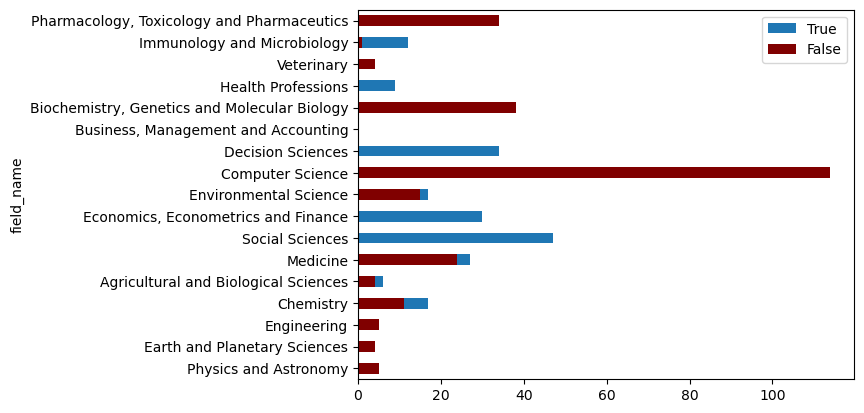

In [71]:
ax = field_name_df2022.plot(x="field_name", y=True, kind="barh") 
field_name_df2022.sort_values(True, ascending=False).plot(x="field_name", y=False, kind="barh", ax=ax, color="maroon")  

<Axes: ylabel='field_name'>

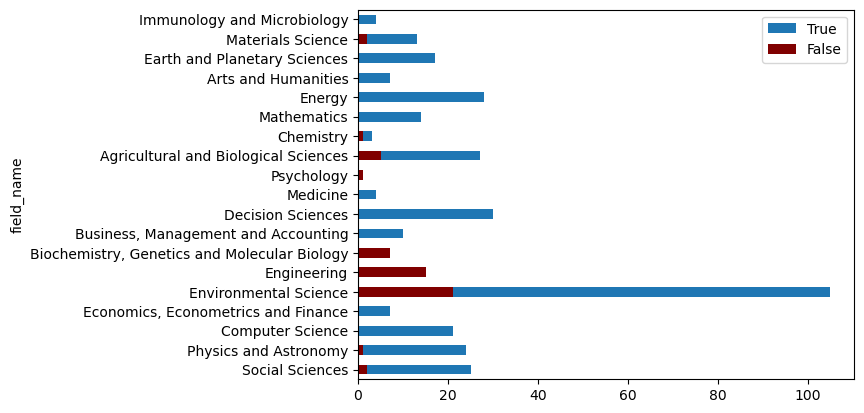

In [72]:
ax = field_name_df2021.plot(x="field_name", y=True, kind="barh") 
field_name_df2021.sort_values(True, ascending=False).plot(x="field_name", y=False, kind="barh", ax=ax, color="maroon")  

In [73]:
mn_oa_pub_df = multiple_counts('institution_name', 'publication_year', 'is_oa', 'OA %', MN_df).sort_values(by=['publication_year'], ascending=False)
mn_oa_pub_df

is_oa,institution_name,publication_year,False,True,OA %
19,University of Minnesota,2024,16.0,5.0,0.238095
18,University of Minnesota,2023,14.0,57.0,0.802817
17,University of Minnesota,2022,229.0,148.0,0.392573
16,University of Minnesota,2021,0.0,53.0,1.000000
15,University of Minnesota,2020,10.0,144.0,0.935065
14,University of Minnesota,2019,8.0,104.0,0.928571
13,University of Minnesota,2018,5.0,105.0,0.954545
12,University of Minnesota,2017,6.0,8.0,0.571429
11,University of Minnesota,2016,10.0,29.0,0.743590
10,University of Minnesota,2015,0.0,4.0,1.000000


Text(0.5, 1.0, 'MN Datasets Publication Year OA %')

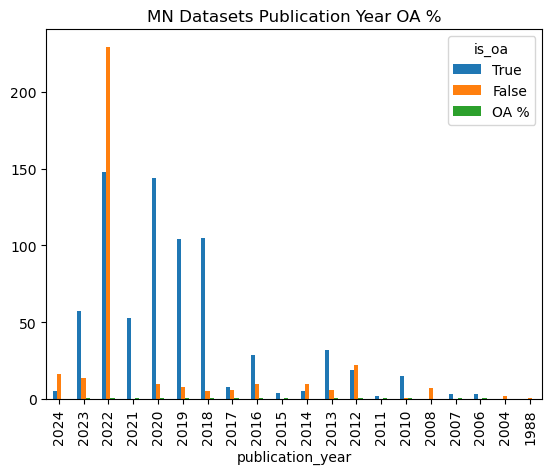

In [74]:
MN_oa_pub_plot = mn_oa_pub_df.plot(x="publication_year", y=[True, False,'OA %'], kind="bar")
MN_oa_pub_plot.set_title('MN Datasets Publication Year OA %')

In [75]:
df.columns

Index(['id', 'doi', 'type', 'funding_type', 'title', 'publication_year',
       'publication_date', 'language', 'topic_id', 'topic_name', 'subfield_id',
       'subfield_name', 'field_id', 'field_name', 'domain_id', 'domain_name',
       'retracted', 'index location', 'Repository', 'is_oa', 'oa_status',
       'license', 'author_id', 'author_name', 'author_position', 'orcid',
       'institution_id', 'institution_name', 'raw_affiliation_strings',
       'country_code', 'ror', 'lineage'],
      dtype='object')

In [76]:
oa_satatus_2022df = oa_status(df2022, 'publication_year', 'oa_status', 'publication_year')
oa_satatus_2022df

oa_status,publication_year,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,2025,0.0,4.0,0.0,0.0,0.0,4.0,0.000000,0.000000,0.000000,1.000000,0.000000,closed
1,2024,4.0,274.0,138.0,27.0,0.0,443.0,0.000000,0.060948,0.311512,0.618510,0.009029,closed
2,2023,9.0,907.0,4432.0,1.0,8.0,5357.0,0.001493,0.000187,0.827329,0.169311,0.001680,gold
3,2022,9.0,9181.0,4960.0,9.0,434115.0,448274.0,0.968414,0.000020,0.011065,0.020481,0.000020,hybrid


In [77]:
oa_satatus_2021df = oa_status(df2021, 'publication_year', 'oa_status', 'publication_year')
oa_satatus_2021df

oa_status,publication_year,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,2021,15.0,2388.0,2874.0,18.0,165.0,5460.0,0.030220,0.003297,0.526374,0.437363,0.002747,gold
1,2020,28.0,1771.0,13413.0,18.0,108.0,15338.0,0.007041,0.001174,0.874495,0.115465,0.001826,gold
2,2019,28.0,1230.0,12686.0,9.0,83.0,14036.0,0.005913,0.000641,0.903819,0.087632,0.001995,gold
3,2018,78.0,153.0,3983.0,32.0,129.0,4375.0,0.029486,0.007314,0.910400,0.034971,0.017829,gold
4,2017,46.0,88.0,1165.0,28.0,65.0,1392.0,0.046695,0.020115,0.836925,0.063218,0.033046,gold
5,2016,431.0,194.0,163.0,11.0,266.0,1065.0,0.249765,0.010329,0.153052,0.182160,0.404695,bronze
6,2015,13.0,75.0,239.0,5.0,23.0,355.0,0.064789,0.014085,0.673239,0.211268,0.036620,gold
7,2014,2.0,89.0,110.0,21.0,32.0,254.0,0.125984,0.082677,0.433071,0.350394,0.007874,gold
8,2013,5.0,102.0,630.0,15.0,5.0,757.0,0.006605,0.019815,0.832232,0.134742,0.006605,gold
9,2012,1.0,117.0,1139.0,15.0,177.0,1449.0,0.122153,0.010352,0.786059,0.080745,0.000690,gold


In [78]:
mn_oa_pub_df = multiple_counts('institution_name', 'publication_year', 'is_oa', 'OA %', MN_df).sort_values(by=['publication_year'], ascending=False)
mn_oa_pub_df

is_oa,institution_name,publication_year,False,True,OA %
19,University of Minnesota,2024,16.0,5.0,0.238095
18,University of Minnesota,2023,14.0,57.0,0.802817
17,University of Minnesota,2022,229.0,148.0,0.392573
16,University of Minnesota,2021,0.0,53.0,1.000000
15,University of Minnesota,2020,10.0,144.0,0.935065
14,University of Minnesota,2019,8.0,104.0,0.928571
13,University of Minnesota,2018,5.0,105.0,0.954545
12,University of Minnesota,2017,6.0,8.0,0.571429
11,University of Minnesota,2016,10.0,29.0,0.743590
10,University of Minnesota,2015,0.0,4.0,1.000000


<Axes: xlabel='publication_year'>

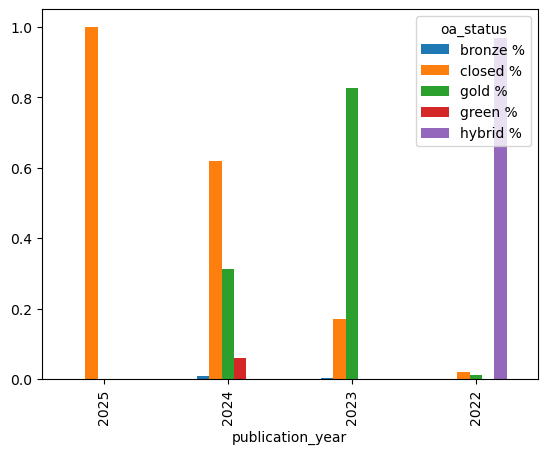

In [79]:
oa_satatus_2022plot = oa_satatus_2022df.plot(x="publication_year", y=["bronze %", "closed %", "gold %", "green %", "hybrid %"], kind="bar")
oa_satatus_2022plot

<Axes: xlabel='publication_year'>

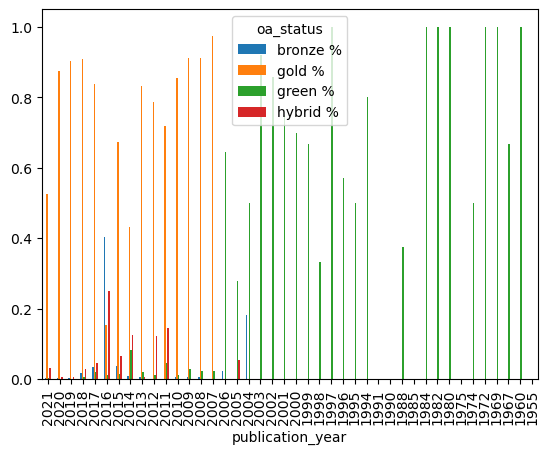

In [80]:
oa_satatus_2021plot = oa_satatus_2021df.plot(x="publication_year", y=["bronze %", "gold %", "green %", "hybrid %"], kind="bar")
oa_satatus_2021plot

In [81]:
df2000 = df[df['publication_year'] >= 2000]
oa_satatus_2000df = oa_status(df2000, 'publication_year', 'oa_status', 'publication_year')
oa_satatus_2000df


oa_status,publication_year,bronze,closed,gold,green,hybrid,total,hybrid %,green %,gold %,closed %,bronze %,Most used OA type
0,2025,0.0,4.0,0.0,0.0,0.0,4.0,0.000000,0.000000,0.000000,1.000000,0.000000,closed
1,2024,4.0,274.0,138.0,27.0,0.0,443.0,0.000000,0.060948,0.311512,0.618510,0.009029,closed
2,2023,9.0,907.0,4432.0,1.0,8.0,5357.0,0.001493,0.000187,0.827329,0.169311,0.001680,gold
3,2022,9.0,9181.0,4960.0,9.0,434115.0,448274.0,0.968414,0.000020,0.011065,0.020481,0.000020,hybrid
4,2021,15.0,2388.0,2874.0,18.0,165.0,5460.0,0.030220,0.003297,0.526374,0.437363,0.002747,gold
5,2020,28.0,1771.0,13413.0,18.0,108.0,15338.0,0.007041,0.001174,0.874495,0.115465,0.001826,gold
6,2019,28.0,1230.0,12686.0,9.0,83.0,14036.0,0.005913,0.000641,0.903819,0.087632,0.001995,gold
7,2018,78.0,153.0,3983.0,32.0,129.0,4375.0,0.029486,0.007314,0.910400,0.034971,0.017829,gold
8,2017,46.0,88.0,1165.0,28.0,65.0,1392.0,0.046695,0.020115,0.836925,0.063218,0.033046,gold
9,2016,431.0,194.0,163.0,11.0,266.0,1065.0,0.249765,0.010329,0.153052,0.182160,0.404695,bronze


<Axes: xlabel='publication_year'>

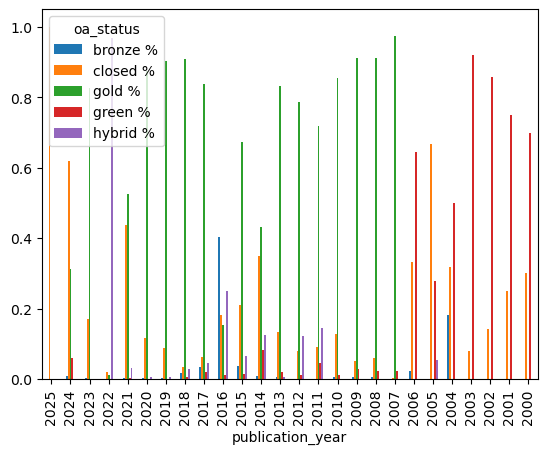

In [82]:
oa_satatus_2000plot = oa_satatus_2000df.plot(x="publication_year", y=["bronze %", "closed %", "gold %", "green %", "hybrid %"], kind="bar")
oa_satatus_2000plot